# Taller 1 — Macroeconomía 3: Ciclos Económicos

**Objetivo:** Este notebook es la Fase 1 (Punto 1) del taller. Cargamos y exploramos datos macroeconómicos de Estados Unidos (FRED), generamos estadísticas descriptivas, visualizamos 7 series económicas trimestrales e identificamos períodos con variación negativa del PIB real.

## 1. Paths & Folders (Detección automática y creación)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Detect ROOT by searching upwards for 'data' folder
current = Path.cwd()
ROOT = None

for parent in current.parents:
    if (parent / 'data').exists():
        ROOT = parent
        break

if ROOT is None:
    # Fallback: assume ROOT is current working directory if 'data' exists locally
    if (current / 'data').exists():
        ROOT = current
    else:
        raise FileNotFoundError("Could not find 'data' folder. Please run from project root.")

# Define paths
DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROC = ROOT / 'data' / 'processed'
OUT_FIG = ROOT / 'outputs' / 'figures'
OUT_TAB = ROOT / 'outputs' / 'tables'
OUT_EXP = ROOT / 'outputs' / 'exports'

# Create directories if they don't exist
OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB.mkdir(parents=True, exist_ok=True)
OUT_EXP.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"DATA_RAW: {DATA_RAW}")
print(f"DATA_PROC: {DATA_PROC}")
print(f"OUT_FIG: {OUT_FIG}")
print(f"OUT_TAB: {OUT_TAB}")
print(f"OUT_EXP: {OUT_EXP}")

ROOT: /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos
DATA_RAW: /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/data/raw
DATA_PROC: /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/data/processed
OUT_FIG: /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/outputs/figures
OUT_TAB: /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/outputs/tables
OUT_EXP: /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/outputs/exports


## 2. Decisiones Económicas: País, Variables y Transformaciones

### País y Fuente de Datos
**Estados Unidos (FRED)** con frecuencia objetivo **trimestral**.

### Motivación
1. **Disponibilidad y calidad:** El Federal Reserve Economic Data (FRED) ofrece series de alta calidad y consistencia temporal.
2. **Evaluación del filtro HP:** Utilizamos un país desarrollado para validar cómo se ajusta el filtro Hodrick-Prescott en una economía madura.
3. **Comparación conceptual:** Exploraremos si las dinámicas económicas estadounidenses difieren significativamente de las observadas en Colombia, permitiendo futuros análisis comparativos.

### Variables Elegidas
- **GDP (Producto Interno Bruto real):** Medida de actividad económica agregada.
- **Consumo (PCECC96):** Gasto en consumo personal en dólares encadenados 2012.
- **Inversión (GPDIC1):** Inversión fija privada doméstica en dólares encadenados 2012.
- **Desempleo (UNRATE):** Tasa de desempleo (porcentaje).
- **Inflación (GDPDEF):** Deflactor del PIB, refleja cambios de precios en la economía.
- **Tasa de política (FEDFUNDS):** Tasa de fondos federales, herramienta de política monetaria de la Fed.

### Propósito
1. **Corto plazo:** Estudiar brechas de componentes del PIB (tendencia vs. ciclo) para entender dinámicas de consumo e inversión.
2. **Extensión futura:** Explorar relaciones empíricas entre brecha del PIB, desempleo e inflación (curva de Phillips, ley de Okun).

### Transformaciones Aplicadas
- **UNRATE y FEDFUNDS (mensual → trimestral):** Promedio simple de tres observaciones mensuales por trimestre.
- **GDP Var (tasa de crecimiento anualizada):** $\text{GDP Var} = 400 \times \Delta \log(\text{GDP})$
- **Inflación (tasa anualizada):** $\text{inflation} = 400 \times \Delta \log(\text{GDPDEF})$

## 3. Cargar Dataset Limpio

In [2]:
# Load dataset from processed folder
xlsx_file = DATA_PROC / 'dataset_taller.xlsx'
csv_file = DATA_PROC / 'dataset_taller.csv'

# Prefer xlsx if it exists, otherwise use csv
if xlsx_file.exists():
    df = pd.read_excel(xlsx_file)
    print(f"Loaded from: {xlsx_file}")
elif csv_file.exists():
    df = pd.read_csv(csv_file)
    print(f"Loaded from: {csv_file}")
else:
    raise FileNotFoundError(f"Neither {xlsx_file} nor {csv_file} found.")

# Ensure 'date' column is datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by date
df = df.sort_values('date').reset_index(drop=True)

print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nFirst 5 rows:")
print(df.head())

Loaded from: /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/data/processed/dataset_taller.xlsx

Dataset shape: (285, 8)
Date range: 1954-12-31 00:00:00 to 2025-12-31 00:00:00

First 5 rows:
        date       GDP    GDP Var  consumption  investment  unemployment  \
0 1954-12-31  2936.852   7.752247     1761.703     295.882      5.333333   
1 1955-03-31  3020.746  11.266225     1801.231     325.442      4.733333   
2 1955-06-30  3069.910   6.457770     1835.737     345.235      4.400000   
3 1955-09-30  3111.379   5.367116     1858.411     350.533      4.100000   
4 1955-12-31  3130.068   2.395477     1881.748     358.661      4.233333   

   inflation  fedfunds  
0   1.088836  0.986667  
1   1.876424  1.343333  
2   1.634681  1.500000  
3   2.786861  1.940000  
4   3.943755  2.356667  


In [3]:
# Data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isna().sum())

Data Types:
date            datetime64[us]
GDP                    float64
GDP Var                float64
consumption            float64
investment             float64
unemployment           float64
inflation              float64
fedfunds               float64
dtype: object

Missing Values:
date            0
GDP             0
GDP Var         0
consumption     0
investment      0
unemployment    0
inflation       0
fedfunds        0
dtype: int64


## 4. Tabla Descriptiva

In [9]:
# Calculate descriptive statistics
desc = df.describe()

print("Estadísticas descriptivas:")
print(desc)

# Save to Excel and CSV
desc_xlsx = OUT_TAB / 'descriptivas.xlsx'
desc_csv = OUT_TAB / 'descriptivas.csv'

desc.to_excel(desc_xlsx)
desc.to_csv(desc_csv)

print(f"\n✓ Descriptivas guardadas en:")
print(f"  - {desc_xlsx}")
print(f"  - {desc_csv}")

# Display table in notebook
display(desc)

Estadísticas descriptivas:
                             date           GDP     GDP Var   consumption  \
count                         285    285.000000  285.000000    285.000000   
mean   1990-06-30 17:20:50.526315  11171.046460    2.982098   7325.783154   
min           1954-12-31 00:00:00   2936.852000  -32.817282   1761.703000   
25%           1972-09-30 00:00:00   5814.854000    1.363555   3627.904000   
50%           1990-06-30 00:00:00   9998.704000    3.072509   6353.139000   
75%           2008-03-31 00:00:00  16561.866000    4.652841  11158.801000   
max           2025-12-31 00:00:00  24111.830000   29.902999  16682.486000   
std                           NaN   6132.245876    4.293595   4296.585823   

        investment  unemployment   inflation    fedfunds  
count   285.000000    285.000000  285.000000  285.000000  
mean   1724.597389      5.801930    3.177520    4.616339  
min     288.010000      3.400000   -1.595072    0.060000  
25%     669.438000      4.500000    1.65568

,date,GDP,GDP Var,consumption,investment,unemployment,inflation,fedfunds
count,285,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000
mean,1990-06-30 17:20:50.526315,11171.046460,2.982098,7325.783154,1724.597389,5.801930,3.177520,4.616339
min,1954-12-31 00:00:00,2936.852000,-32.817282,1761.703000,288.010000,3.400000,-1.595072,0.060000
25%,1972-09-30 00:00:00,5814.854000,1.363555,3627.904000,669.438000,4.500000,1.655683,1.940000
50%,1990-06-30 00:00:00,9998.704000,3.072509,6353.139000,1279.695000,5.533333,2.482213,4.330000
75%,2008-03-31 00:00:00,16561.866000,4.652841,11158.801000,2638.672000,6.833333,4.033509,6.220000
max,2025-12-31 00:00:00,24111.830000,29.902999,16682.486000,4547.947000,13.000000,11.596345,17.780000
std,NaN,6132.245876,4.293595,4296.585823,1206.133034,1.665455,2.264473,3.525180


## 5. Gráficos Individuales por Variable (7 Series)

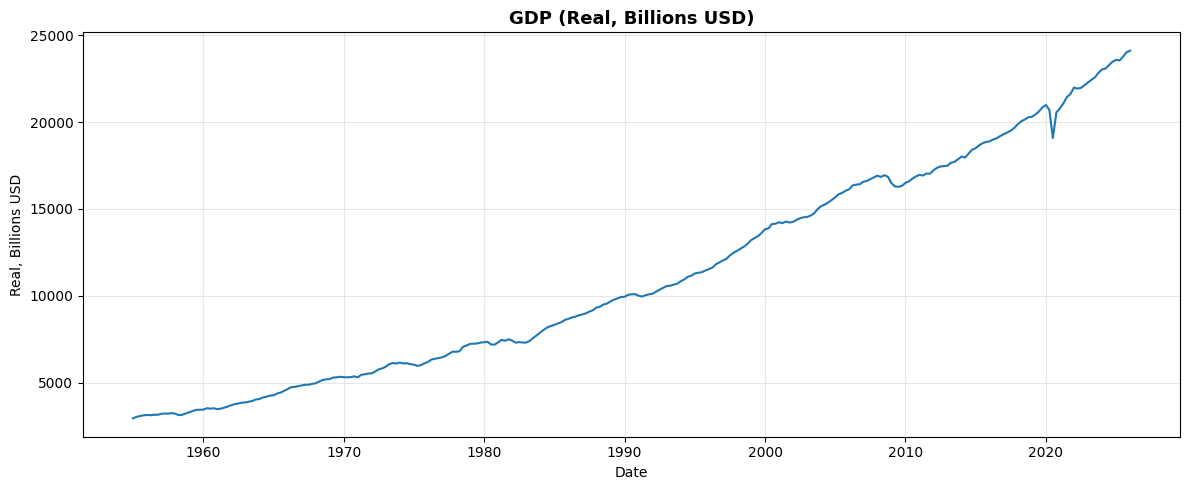

✓ 01_GDP.png saved


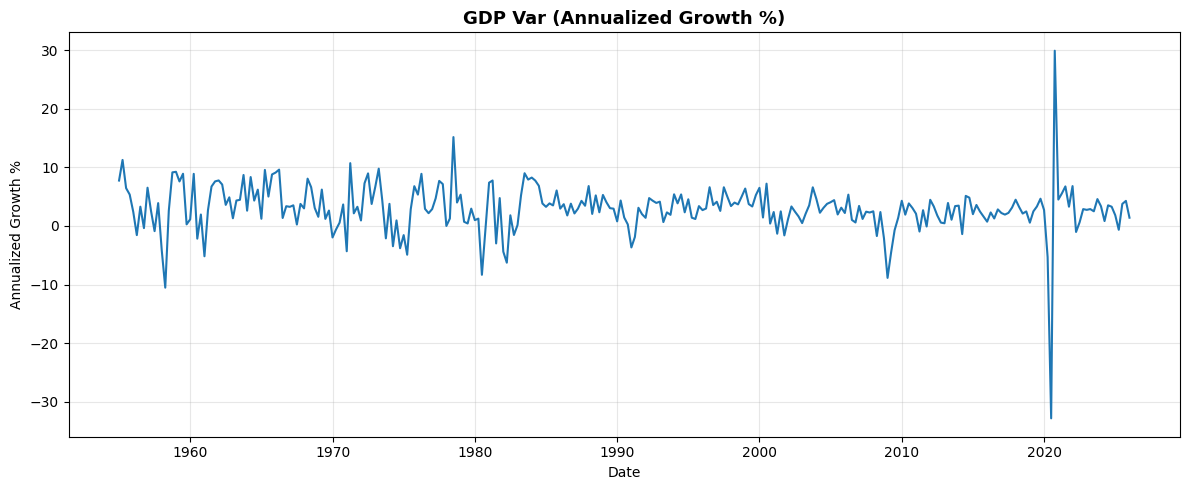

✓ 02_GDP_Var.png saved


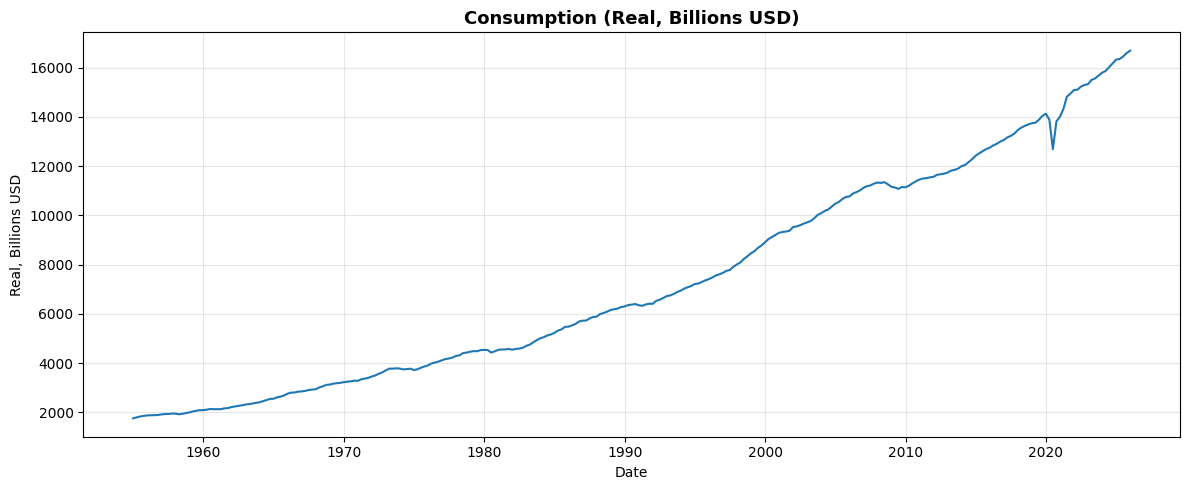

✓ 03_consumption.png saved


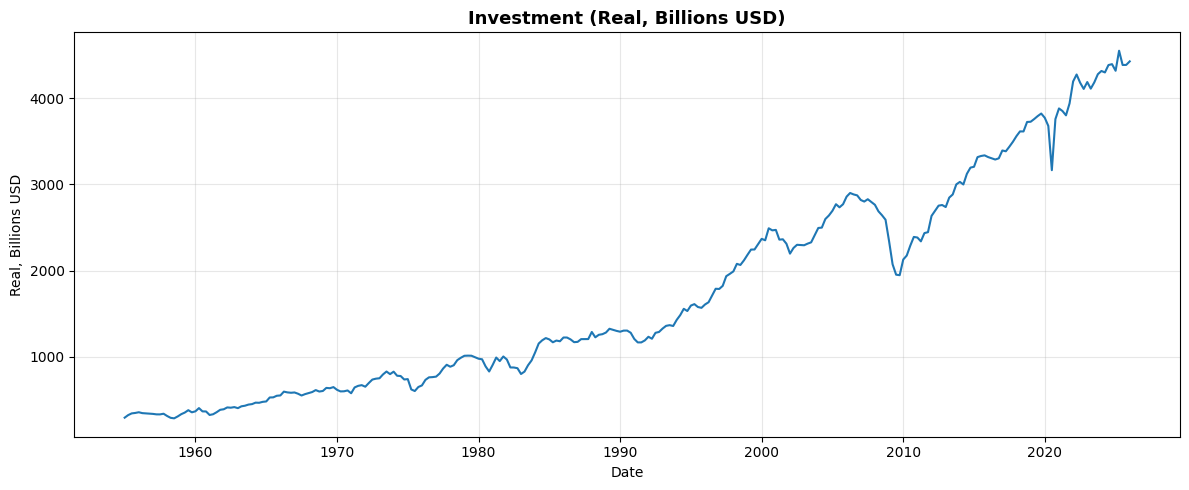

✓ 04_investment.png saved


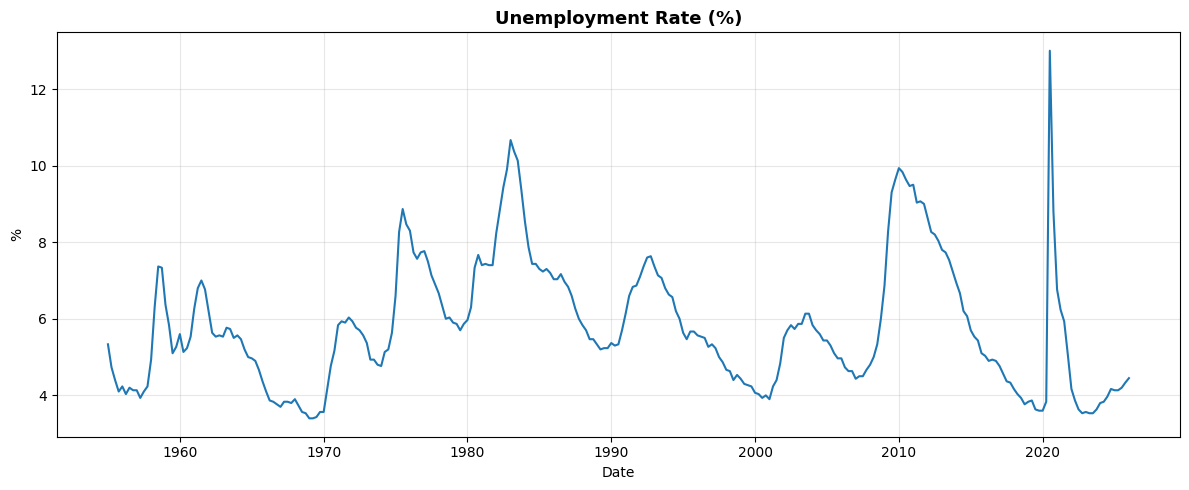

✓ 05_unemployment.png saved


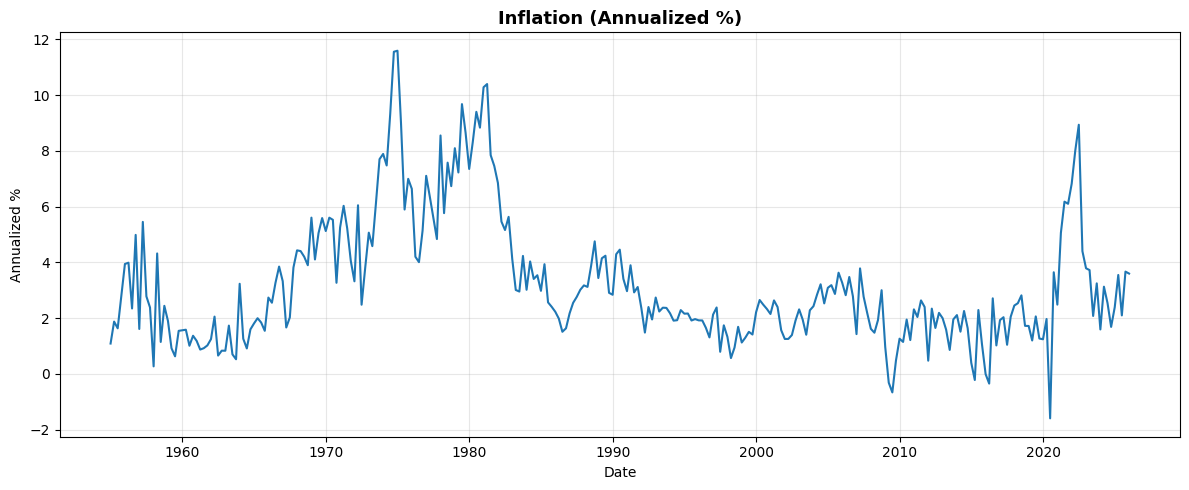

✓ 06_inflation.png saved


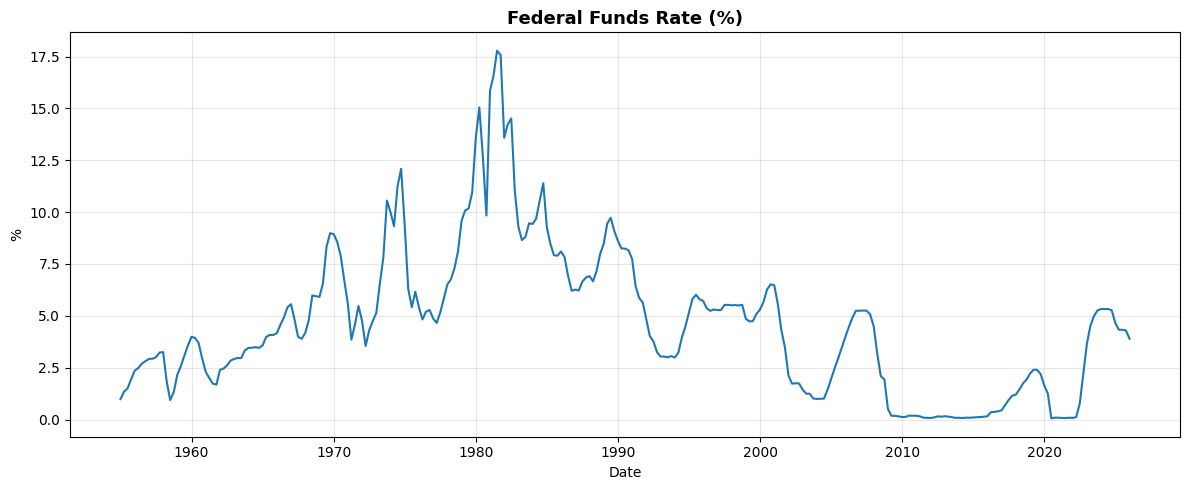

✓ 07_fedfunds.png saved

All figures saved to: /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/outputs/figures


In [10]:
# Define variables to plot
variables = [
    ('GDP', 'GDP (Real, Billions USD)'),
    ('GDP Var', 'GDP Var (Annualized Growth %)'),
    ('consumption', 'Consumption (Real, Billions USD)'),
    ('investment', 'Investment (Real, Billions USD)'),
    ('unemployment', 'Unemployment Rate (%)'),
    ('inflation', 'Inflation (Annualized %)'),
    ('fedfunds', 'Federal Funds Rate (%)')
]

fig_filenames = [
    '01_GDP.png',
    '02_GDP_Var.png',
    '03_consumption.png',
    '04_investment.png',
    '05_unemployment.png',
    '06_inflation.png',
    '07_fedfunds.png'
]

# Create individual plots
for (var, title), filename in zip(variables, fig_filenames):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df['date'], df[var], linewidth=1.5)
    ax.set_xlabel('Date')
    ax.set_ylabel(title.split('(')[1].strip(')'))
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save figure
    fig_path = OUT_FIG / filename
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    
    # Display figure in notebook
    plt.show()
    plt.close()
    
    print(f"✓ {filename} saved")

print(f"\nAll figures saved to: {OUT_FIG}")

## 6. Tabla de Períodos con GDP Var < 0

In [11]:
# Create recession table (periods with negative GDP growth)
df_recess = df[df['GDP Var'] < 0][['date', 'GDP Var']].copy()

# Save to Excel and CSV
recess_xlsx = OUT_TAB / 'gdp_var_negativa.xlsx'
recess_csv = OUT_TAB / 'gdp_var_negativa.csv'

df_recess.to_excel(recess_xlsx, index=False)
df_recess.to_csv(recess_csv, index=False)

print(f"Total quarters with GDP Var < 0: {len(df_recess)}")
print(f"\nFirst 10 quarters:")
print(df_recess.head(10))

print(f"\n✓ Recession table saved to:")
print(f"  - {recess_xlsx}")
print(f"  - {recess_csv}")

# Display full table in notebook
display(df_recess)

Total quarters with GDP Var < 0: 37

First 10 quarters:
         date    GDP Var
5  1956-03-31  -1.555190
7  1956-09-30  -0.358975
10 1957-06-30  -0.877523
12 1957-12-31  -4.159708
13 1958-03-31 -10.520768
22 1960-06-30  -2.159247
24 1960-12-31  -5.165738
60 1969-12-31  -1.957619
61 1970-03-31  -0.596011
64 1970-12-31  -4.309423

✓ Recession table saved to:
  - /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/outputs/tables/gdp_var_negativa.xlsx
  - /Users/santi/Documents/EAFIT/2026-1/CiclosEconomicos/ciclos_economicos/outputs/tables/gdp_var_negativa.csv


,date,GDP Var
5,1956-03-31,-1.555190
7,1956-09-30,-0.358975
10,1957-06-30,-0.877523
12,1957-12-31,-4.159708
13,1958-03-31,-10.520768
22,1960-06-30,-2.159247
24,1960-12-31,-5.165738
60,1969-12-31,-1.957619
61,1970-03-31,-0.596011
64,1970-12-31,-4.309423


## 7. Interpretación y Prompts para Análisis Posterior

### 📝 Sección a completar

En esta sección se presentará un análisis descriptivo de los datos cargados. Para completar, responder a las siguientes preguntas y prompts:

#### **Volatilidad Relativa**
- [ ] ¿Qué series parecen más volátiles? (comparar desviaciones estándar)
- [ ] ¿GDP Var tiene mayor volatilidad que GDP? ¿Por qué?
- [ ] ¿Cómo se compara la volatilidad de inversión respecto a consumo?

#### **Episodios Económicos Clave**
- [ ] Identificar episodios históricos: picos de inflación (¿cuándo y cuánto?)
- [ ] ¿En qué períodos la tasa Fed Funds estuvo cercana a cero?
- [ ] ¿Cambios de régimen en desempleo o inflación?
- [ ] ¿Cuántas recesiones identifica en el período (GDP Var < 0)?

#### **Coherencia Macroeconómica**
- [ ] Relación cualitativa entre GDP Var y unemployment: ¿desaceleración del PIB coincide con aumento de desempleo?
- [ ] ¿Caídas de inversión anticipan o acompañan caídas de consumo?
- [ ] ¿Episodios inflacionarios coinciden con períodos de bajo desempleo?

#### **Preparación para Fase 2 (Filtro HP)**
- [ ] ¿Qué series serían candidatos naturales para separar tendencia/ciclo?
- [ ] ¿Espera que el filtro HP revele ciclos más suaves o más pronunciados de lo que la serie cruda sugiere?

## 8. Verificación de Outputs Generados

In [12]:
# List all generated figures
print("=" * 70)
print("FIGURAS GENERADAS (outputs/figures):")
print("=" * 70)

for fig_file in sorted(OUT_FIG.glob('*.png')):
    print(f"✓ {fig_file.name} ({fig_file.stat().st_size / 1024:.1f} KB)")

print()
print("=" * 70)
print("TABLAS GENERADAS (outputs/tables):")
print("=" * 70)

for table_file in sorted(OUT_TAB.glob('*')):
    if table_file.is_file():
        print(f"✓ {table_file.name} ({table_file.stat().st_size / 1024:.1f} KB)")

print()
print("=" * 70)
print("RESUMEN:")
print("=" * 70)
print(f"✓ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"✓ Rango temporal: {df['date'].min().date()} a {df['date'].max().date()}")
print(f"✓ Figuras PNG generadas: {len(list(OUT_FIG.glob('*.png')))}")
print(f"✓ Tablas Excel/CSV generadas: {len(list(OUT_TAB.glob('*')))}")
print(f"✓ Períodos con GDP Var < 0: {len(df_recess)}")
print("\n✓ Notebook Taller_1 completado exitosamente.")

FIGURAS GENERADAS (outputs/figures):
✓ 01_GDP.png (54.7 KB)
✓ 02_GDP_Var.png (93.4 KB)
✓ 03_consumption.png (58.8 KB)
✓ 04_investment.png (63.3 KB)
✓ 05_unemployment.png (78.3 KB)
✓ 06_inflation.png (103.8 KB)
✓ 07_fedfunds.png (79.0 KB)

TABLAS GENERADAS (outputs/tables):
✓ descriptivas.csv (0.9 KB)
✓ descriptivas.xlsx (5.6 KB)
✓ gdp_var_negativa.csv (1.1 KB)
✓ gdp_var_negativa.xlsx (5.7 KB)

RESUMEN:
✓ Dataset cargado: 285 filas × 8 columnas
✓ Rango temporal: 1954-12-31 a 2025-12-31
✓ Figuras PNG generadas: 7
✓ Tablas Excel/CSV generadas: 4
✓ Períodos con GDP Var < 0: 37

✓ Notebook Taller_1 completado exitosamente.
